In [1]:
from pathlib import Path
import os
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print(Path.cwd())
os.chdir(Path.cwd().parent)
print(Path.cwd())

/Users/olejurgensen/Desktop/KidsARC/AmbigousARC/_notebooks
/Users/olejurgensen/Desktop/KidsARC/AmbigousARC


## Load and Preprocess Data

### Load human and LLM responses, run eval

In [3]:
from utils.eval import Eval
from utils.human_eval import HumanEval

gen_llm = Eval('data/results/generation.json')
gen_human = HumanEval('data/human_data_collection/kidsarc.csv', task='generation')

In [4]:
# save preprocessed data
gen_llm.df.to_csv("data/preprocessed/llm_generation.csv", index=False)
gen_human.df.to_csv("data/preprocessed/human_generation.csv", index=False)

### Create summary of items

In [5]:
import json
with open("data/human_data_collection/AmbigousARC.json", "r") as f:
    item_dict = json.load(f)

df = pd.DataFrame(item_dict)[["main_id", "concept", "xdim"]].rename(columns={"xdim": "size"})
items_df = df.drop_duplicates(subset="main_id", keep="first").reset_index(drop=True)

In [6]:
items_df.to_csv("data/preprocessed/items.csv", index=False)

In [17]:
import json
with open("data/ambigous_arc.json", "r") as f:
    item_list = json.load(f)

items_df = pd.DataFrame(item_list)[["id", "concept", "xdim"]].rename(columns={"xdim": "size"})
items_df

,id,concept,size
0,02ue5B,order,5
1,02wXdR,fill_in,3
2,0Zgi5T,keep_above_or_below,3
3,15a8kn,horizontal_and_vertical,5
4,1Gjg7C,clean_up,3
...,...,...,...
104,ZLuqmG,foreground_and_background,5
105,zmTsWK,foreground_and_background,3
106,ZunLDt,extend_to_boundary,3
107,ZXSuRo,complete_shape,5


## Item Exploration

In [38]:
items_df.concept.unique()

<StringArray>
[                    'order',                   'fill_in',
       'keep_above_or_below',   'horizontal_and_vertical',
                  'clean_up', 'foreground_and_background',
            'complete_shape',        'extend_to_boundary',
                      'copy',          'move_to_boundary',
        'inside_and_outside']
Length: 11, dtype: str

In [37]:
concepts_ids = items_df[items_df.concept == 'move_to_boundary'].id.values
print(concepts_ids)

<StringArray>
['6t9NbZ', 'btNhEm', 'FZWMao', 'gcKe7t', 'pBTjNa', 'yvToHE']
Length: 6, dtype: str


Response 1 of 100  (mirror 6t9NbZ_1)


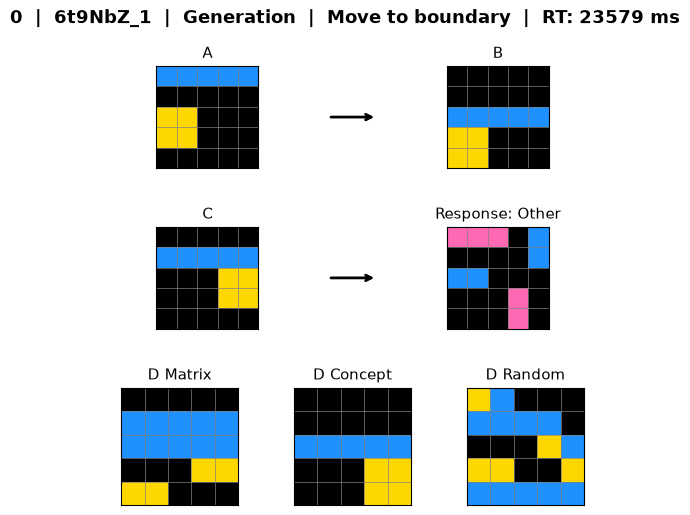

Response 1 of 112  (mirror btNhEm_1)


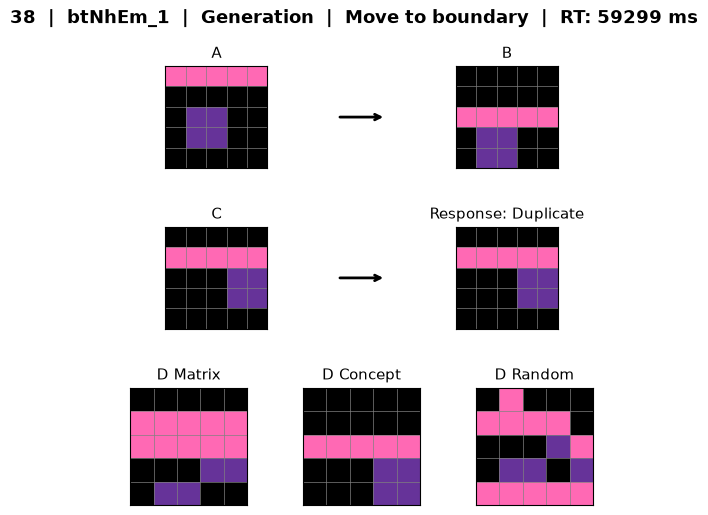

Response 1 of 124  (mirror FZWMao_1)


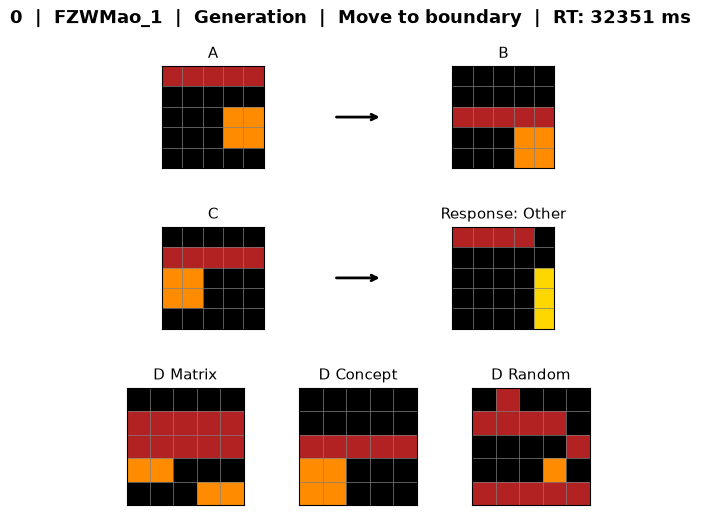

Response 1 of 110  (mirror gcKe7t_1)


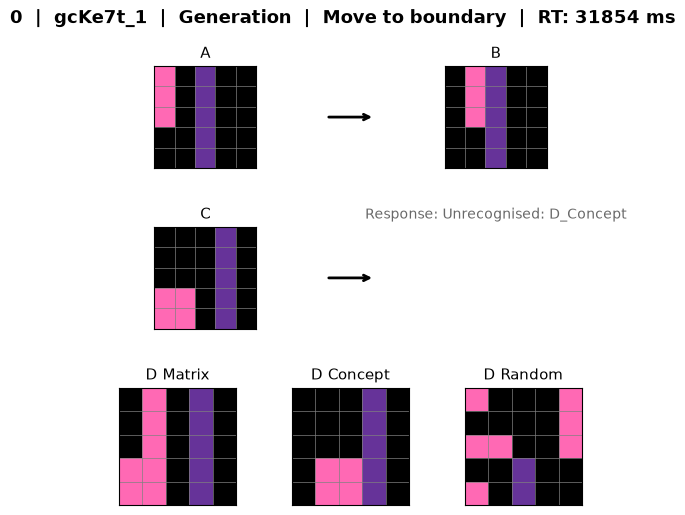

Response 1 of 105  (mirror pBTjNa_1)


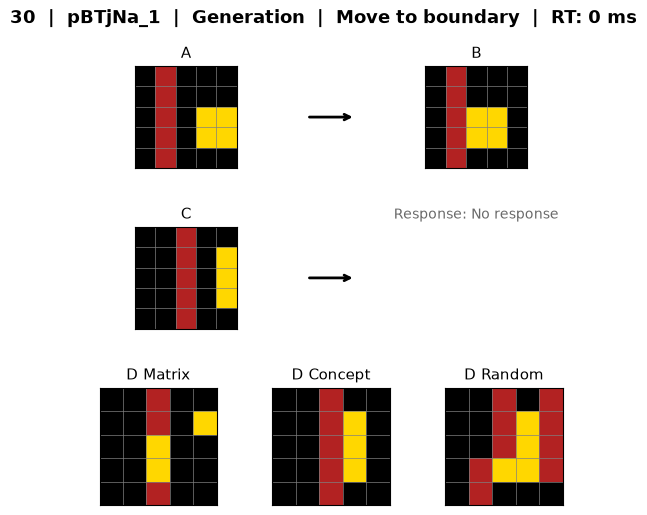

Response 1 of 107  (mirror yvToHE_1)


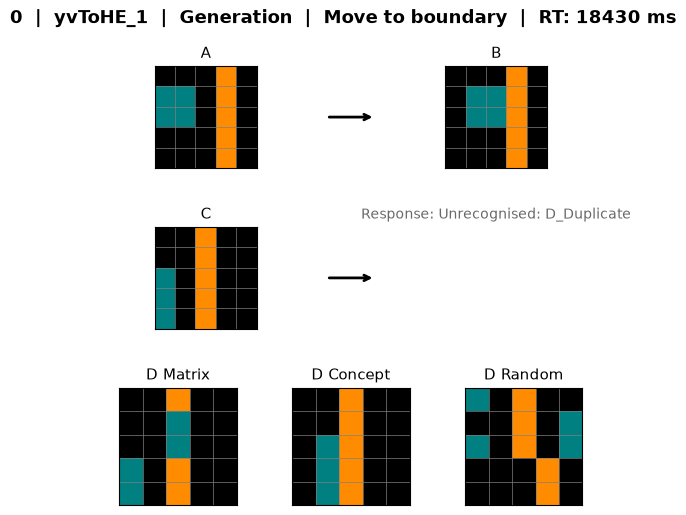

In [39]:
from utils.visualize_responses import ResponseBrowser, plot_response
for item_id in concepts_ids:
    print
    # gen_llm_browser = ResponseBrowser(gen_llm.df, gen_llm.dataset, item_id=item_id)
    gen_human_browser = ResponseBrowser(gen_human.df, "data/human_data_collection/AmbigousARC.json", item_id=item_id)
    gen_human_browser.show()


In [9]:
from utils.visualize_responses import ResponseBrowser, plot_response

item_id =  "GiG6QN"
# Models — items come from the Eval's own dataset
gen_llm_browser =ResponseBrowser(gen_llm.df, gen_llm.dataset, item_id=item_id)
gen_human_browser = ResponseBrowser(gen_human.df, "data/human_data_collection/AmbigousARC.json", item_id=item_id)


Response 60 of 60  (mirror GiG6QN_2)


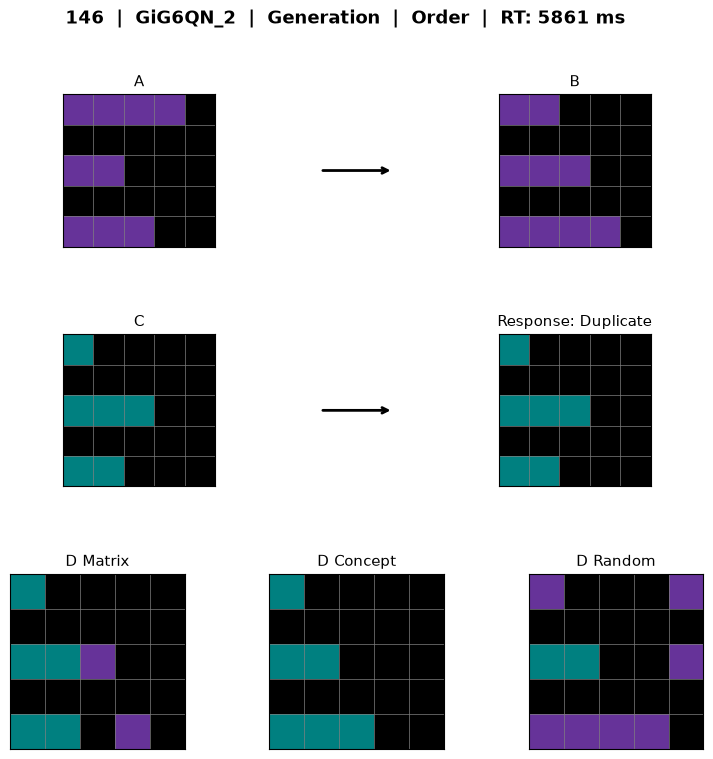

In [67]:
gen_human_browser.next()

Response 20 of 55  (mirror GiG6QN_2)


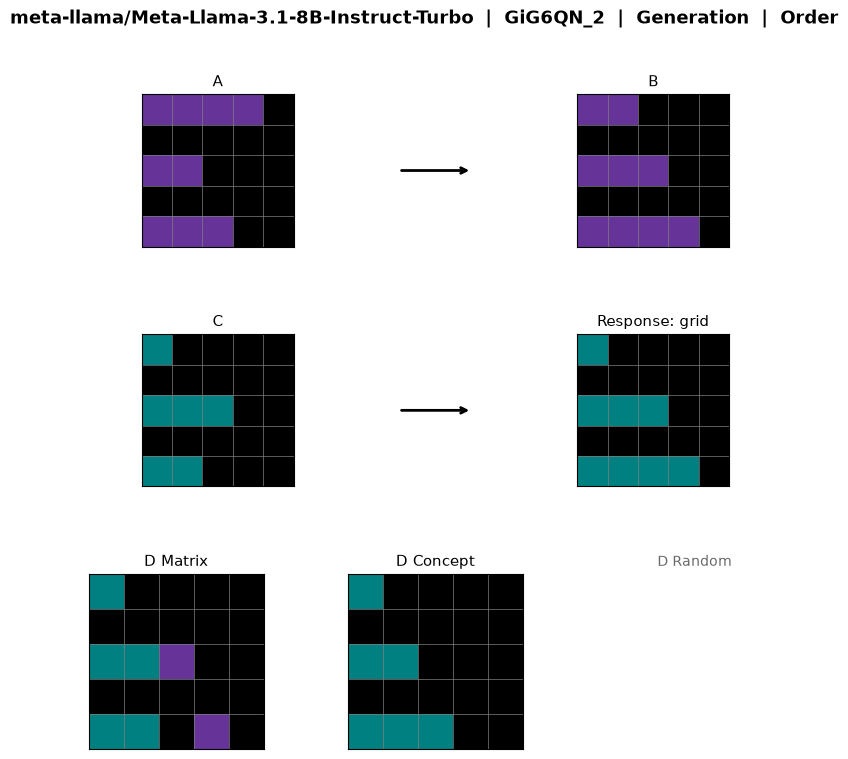

In [234]:
gen_llm_browser.next()

## Data Exploration

In [73]:
print(len(items_df))
print(items_df.concept.nunique())
print(sorted(items_df.concept.unique()))

106
11
['clean_up', 'complete_shape', 'copy', 'extend_to_boundary', 'fill_in', 'foreground_and_background', 'horizontal_and_vertical', 'inside_and_outside', 'keep_above_or_below', 'move_to_boundary', 'order']


In [71]:
concept_counts = (
    items_df["concept"]
    .value_counts()
    .rename_axis("concept")
    .reset_index(name="item_count")
    .sort_values("concept")
)

print(concept_counts.to_string(index=False))

                  concept  item_count
                 clean_up          12
           complete_shape           9
                     copy          12
       extend_to_boundary          12
                  fill_in          10
foreground_and_background          12
  horizontal_and_vertical           6
       inside_and_outside           6
      keep_above_or_below           9
         move_to_boundary           6
                    order          12


In [8]:
gen_human.df["participant"].nunique()

1193

In [9]:
gen_llm.df["model"].unique()

<StringArray>
[         'mistralai/Mixtral-8x7B-Instruct-v0.1',
                'Qwen/Qwen2.5-7B-Instruct-Turbo',
               'Qwen/Qwen2.5-72B-Instruct-Turbo',
  'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo',
 'meta-llama/Meta-Llama-3.1-405B-Instruct-Turbo',
                          'google/gemma-2-9b-it',
                         'google/gemma-2-27b-it',
         'mistralai/Mixtral-8x22B-Instruct-v0.1',
   'meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo',
                        'gpt-4-turbo-2024-04-09',
                             'gpt-4o-2024-05-13']
Length: 11, dtype: str

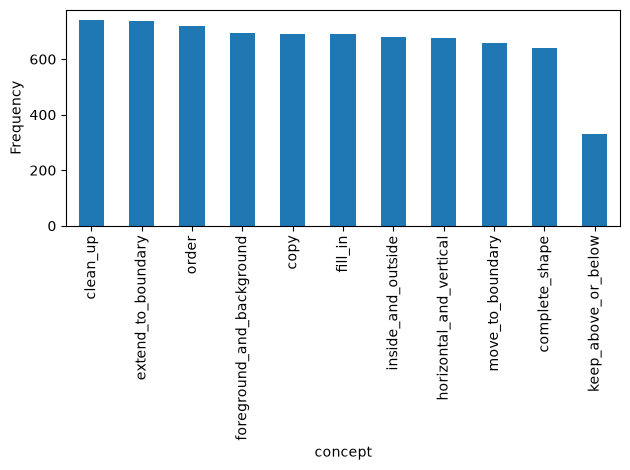

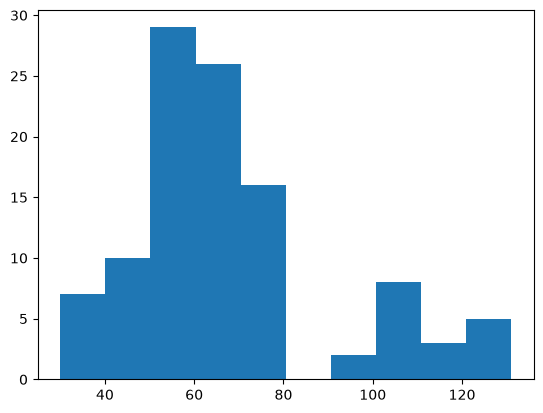

In [ ]:
import matplotlib.pyplot as plt

df = gen_human.df.copy()

concept_counts = df["concept"].value_counts()
concept_counts.plot(kind="bar")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

item_counts = df["item_main_id"].value_counts()
plt.hist(item_counts)
plt.show()

In [241]:
df = pd.read_csv("data/human_data_collection/new_kidsarc.csv")
df["item_id_main"] = df["itemid"].str.split("_").str[0]

display(df.head())
df["item_id_main"].nunique()

,kidsarc_response_id,participant_fk,itemid,response,correct,saveitem_timestamp,rt,task,matrix_level,item_id_main
0,6384,23,GjqiSH_1,0000000000000000000000000,NaN,2024-12-21 17:13:35,813,generation,NaN,GjqiSH
1,6385,23,hC2gHL_1,0000000000000000000000000,NaN,2024-12-21 17:13:35,353,generation,NaN,hC2gHL
2,6386,23,mZ96WW_2,000000000,NaN,2024-12-21 17:13:36,321,generation,NaN,mZ96WW
3,6387,23,zcBCRV_1,0000000000000000000000000,NaN,2024-12-21 17:13:36,329,generation,NaN,zcBCRV
4,6388,23,RebX8D_1,0000000000000000000000000,NaN,2024-12-21 17:13:36,274,generation,NaN,RebX8D


106

Number of participants: 1216
Number of items per participant: 16.35855263157895


(array([  0.,  41.,  18.,  18.,  14.,  63.,  24.,  34.,   5.,   5.,   2.,
          0., 869.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   6.,   1.,   3.,   3.,   0.,   1.,   0.,   1.,
          0.,   2.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.,   3.,  12.,  85.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
        52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
        65., 66., 67., 68., 69., 70., 71., 72., 73., 74., 75.]),
 <BarContainer object of 75 artists>)

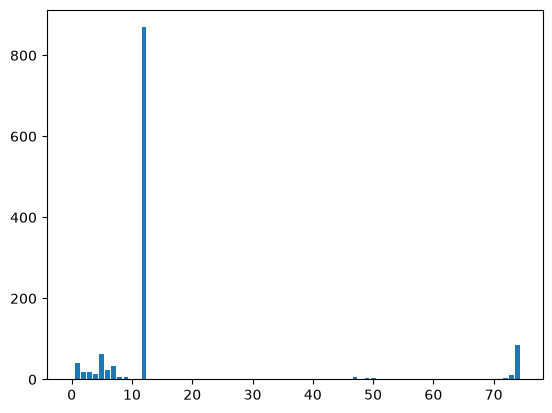

In [76]:
n_items = []
for participant in df['participant_fk'].unique():
    sub_df = df[df['participant_fk'] == participant]
    n_items_p = len(sub_df['itemid'].unique())
    n_items.append(n_items_p)
print(f"Number of participants: {len(df['participant_fk'].unique())}")
print(f"Number of items per participant: {np.mean(n_items)}")
plt.hist(n_items, bins=range(0, max(n_items)+1), align='left', rwidth=0.8)

# User dat exploration

In [3]:
arc_user_df = pd.read_csv("data/human_data_collection/user_kidsarc.csv")
full_user_df = pd.read_csv("data/human_data_collection/user_full.csv")

In [4]:
frequency_table = (
    arc_user_df["research_study"]
    .value_counts(dropna=False)
    .rename_axis("research_study")
    .reset_index(name="frequency")
)

frequency_table

,research_study,frequency
0,AmbiguousARC_NEMO,944
1,UvARECcampusNovDec2025,224
2,AmbiguousARC,142
3,NaN,42
4,kidsARC_ABC2025,4


In [5]:
arc_user_df["participantnr"] = arc_user_df["participantnr"].astype("string")
full_user_df["user_id"] = full_user_df["user_id"].astype("string")

data_dict = {
    "type": [],
    "participant_id": [],
    "participant_id_arc": [],
    "research_study": [],
    "age": [],
    "language": [],
}

def age_mapper(full_rows, arc_rows):
    # Prefer a directly recorded age, first in full_user_df, then arc_user_df.
    for rows in (full_rows, arc_rows):
        if rows.empty:
            continue

        row = rows.iloc[0]
        age = row.get("age")
        dob = row.get("dob")
        timestamp = row.get("created_timestamp")

        if pd.notna(age):
            return age

        if pd.notna(dob) and pd.notna(timestamp):
            completion_year = pd.to_datetime(timestamp).year
            return completion_year - int(dob)

    return None

for participantnr in arc_user_df["participantnr"].dropna().unique():
    arc_rows = arc_user_df[arc_user_df["participantnr"] == participantnr]
    full_rows = full_user_df[full_user_df["user_id"] == participantnr]

    arc_user_id = arc_rows["user_id"].iloc[0]

    if not full_rows.empty:
        participant_type = "event"
        participant_id = participantnr
        research_study = full_rows["research_study"].iloc[0]
        age = age_mapper(full_rows, arc_rows)
        language = full_rows["language"].iloc[0]

    elif "test" in participantnr:
        participant_type = "test"
        participant_id = None
        research_study = None
        age = None
        language = None

    elif "prolific" in participantnr:
        participant_type = "prolific"
        participant_id = None
        research_study = None
        age = age_mapper(full_rows, arc_rows)
        language = None

    else:
        continue

    data_dict["type"].append(participant_type)
    data_dict["participant_id"].append(participant_id)
    data_dict["participant_id_arc"].append(arc_user_id)
    data_dict["research_study"].append(research_study)
    data_dict["age"].append(age)
    data_dict["language"].append(language)

merged_df = pd.DataFrame(data_dict)

merged_df["participant_id"] = pd.to_numeric(
    merged_df["participant_id"],
    errors="coerce"
).astype("Int64")

merged_df = merged_df.sort_values(
    ["participant_id", "type"],
    na_position="last"
).reset_index(drop=True)

merged_df

,type,participant_id,participant_id_arc,research_study,age,language
0,event,1,185,NEMO2025,999.0,NaN
1,event,2,188,NEMO testing,999.0,NaN
2,event,14,228,NEMO2025,999.0,NL
3,event,15,212,NEMO2025,12.0,NL
4,event,16,213,NEMO2025,10.0,NL
...,...,...,...,...,...,...
992,test,<NA>,183,NaN,NaN,NaN
993,test,<NA>,184,NaN,NaN,NaN
994,test,<NA>,194,NaN,NaN,NaN
995,test,<NA>,195,NaN,NaN,NaN


# New item exploration

### load newly created items, filtered by time

In [14]:
new_items_df = pd.read_csv(
    "data/new_items/matrices.csv",
    dtype={"A": str, "B": str, "C": str, "D_Matrix": str, "D_Concept": str},
)

new_items_df["create_date"] = pd.to_datetime(
    new_items_df["create_date"],
    errors="coerce"
)
new_items_df = new_items_df[
    new_items_df["create_date"] > pd.Timestamp("2026-09-28 13:54:00")
]
new_items_df

,id,A,B,C,D_Matrix,D_Concept,concept,create_date
195,JmQQFH,1111100000555550000055555,0000000000555551111155555,0000055555000005555511111,0000000000000000000000000,0000055555111115555500000,inside_and_outside,2026-09-28 14:07:17
253,N9yjC8,7077770000700070000777707,1033310000100010000133301,0000700007777070000000777,0000000000000000000000000,0000100001333010000000333,horizontal_and_vertical,2026-09-28 13:57:47
391,WLWpzN,0010000100110110010000100,0050000500330330050000500,0001011010000000101101000,0000000000000000000000000,0005033050000000503305000,horizontal_and_vertical,2026-09-28 13:55:38
406,xUmo8W,2020520205202052020520205,2520025200252002520025200,0360603606036060360603606,0000000000000000000000000,0063600636006360063600636,inside_and_outside,2026-09-28 14:08:40


### load latest version of items

In [22]:
import json
with open("data/new_items/items_updated.json", "r") as f:
    existing_item_list = json.load(f)


### overview of existing items

In [23]:
existing_item_df = pd.DataFrame(existing_item_list)[["id", "concept", "xdim"]].rename(columns={"xdim": "size"})

counts = pd.crosstab(
    existing_item_df["concept"],
    existing_item_df["size"],
    margins=True,
    margins_name="total",
)
counts

size,3,5,total
concept,,,
clean_up,10,10,20
complete_shape,10,10,20
copy,10,10,20
crush,10,10,20
extend_to_boundary,9,11,20
extend_to_target,8,12,20
fill_in,8,12,20
foreground_and_background,10,10,20
horizontal_and_vertical,0,20,20


In [28]:
print(sorted(existing_item_df["concept"].unique()))
#print(existing_item_df["concept"].nunique())

['clean_up', 'complete_shape', 'copy', 'crush', 'extend_to_boundary', 'extend_to_target', 'fill_in', 'foreground_and_background', 'horizontal_and_vertical', 'keep_above_or_below', 'keep_inside_or_outside', 'move_inside_or_outside', 'move_to_boundary', 'order', 'tetris']


### Quick item visualization

In [20]:
import matplotlib.pyplot as plt
from utils.plot_utils import plot_matrix
from utils.prompt_utils import convert_to_array, get_d_matrix

def view_concept(items, concept, show_matrix=True):
    """One row per item: A, B, C, D_Concept (and the pixel-level D_Matrix)."""
    sel = [i for i in items if i.get('concept') == concept]
    if not sel:
        print(f"No items with concept '{concept}'")
        return
    cols = ['A', 'B', 'C', 'D_Concept'] + (['D_Matrix'] if show_matrix else [])
    fig, axes = plt.subplots(len(sel), len(cols),
                             figsize=(2.1 * len(cols), 2.1 * len(sel)),
                             squeeze=False)
    for r, item in enumerate(sel):
        print(item['id'])
        grids = {c: item[c] for c in cols if c in item}
        if show_matrix:
            grids['D_Matrix'] = get_d_matrix(item, 'pixel')
        for c, name in enumerate(cols):
            plot_matrix(convert_to_array(grids[name], item['xdim']),
                        title=name if r == 0 else '',
                        ax=axes[r][c], size=10)
        axes[r][0].set_ylabel(item['id'], rotation=0, ha='right',
                              va='center', fontsize=9)
    fig.suptitle(f"{concept}  ({len(sel)} items)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

2hmBPx
3m2VvG
69yHy7
8Kzzk2
aP9mhp
JBB0zi
m4YE3m
ScaQgX
vzyqo4
wcncOV
ZLuqmG
zmTsWK
dMhkM5
NQy7Jn
oRo06L
pFgSuz
QDfGeN
ToAPbe
zuZZ7g
tOWmE8


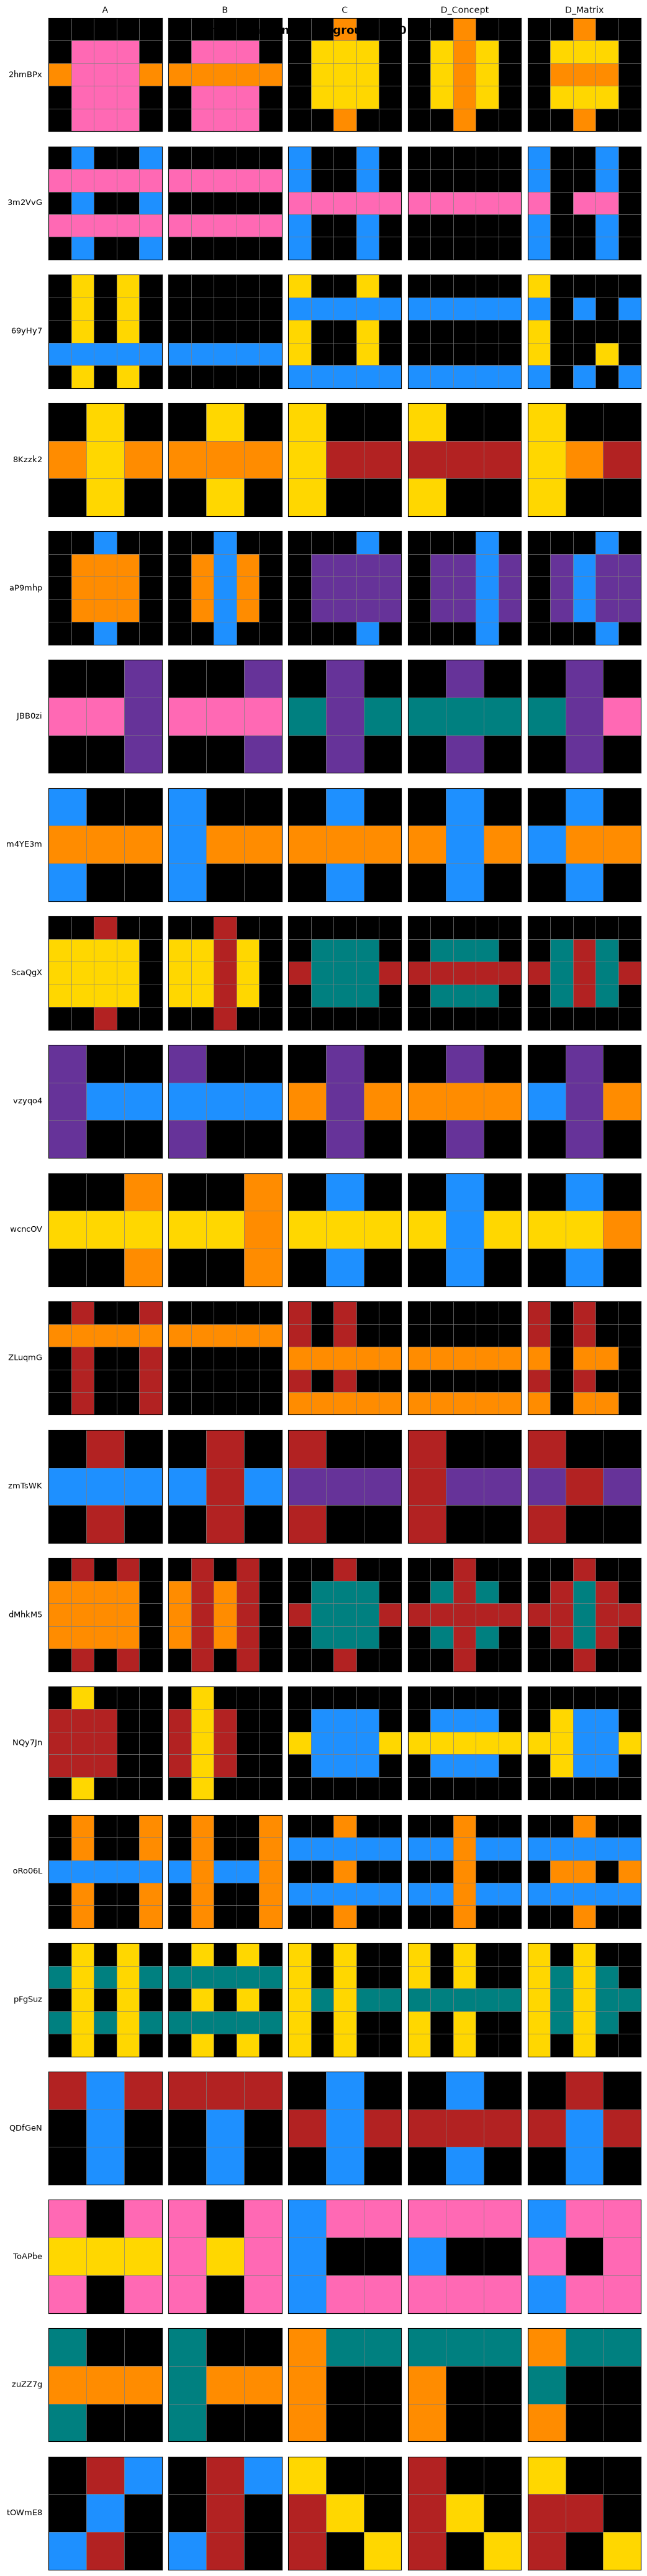

In [21]:
view_concept(existing_item_list, 'foreground_and_background')

### Review new items

In [125]:
from utils.item_review import ItemReviewer

reviewer = ItemReviewer(new_items_df, existing_item_list)
reviewer.report()      # what came in

Existing items:        304
To review:             4
  with problems:       0
  partial grid match:  0
Exact duplicates skipped: 0

Concepts in the new items:
inside_and_outside         2
horizontal_and_vertical    2

Not in the data yet: inside_and_outside
Accepting these needs new_concept=True.


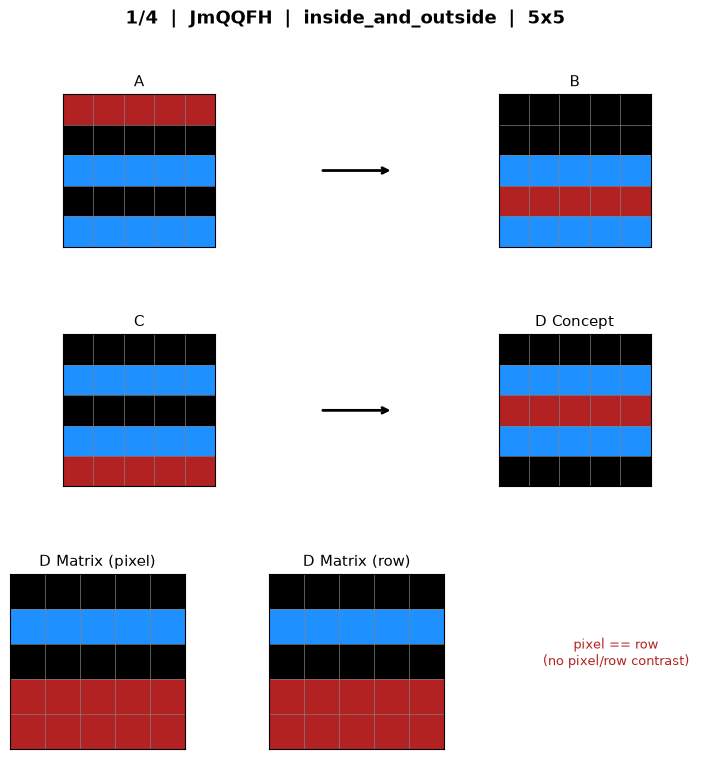

In [126]:
reviewer.show() #/ .previous() / .go_to(i)

In [130]:
reviewer.accept('move_inside_or_outside')                      # keep, concept from CSV

Accepted xUmo8W as 'move_inside_or_outside'  (4 accepted, 0 left)
Review complete.


Rejected fqQYKZ  (1 rejected, 44 left)


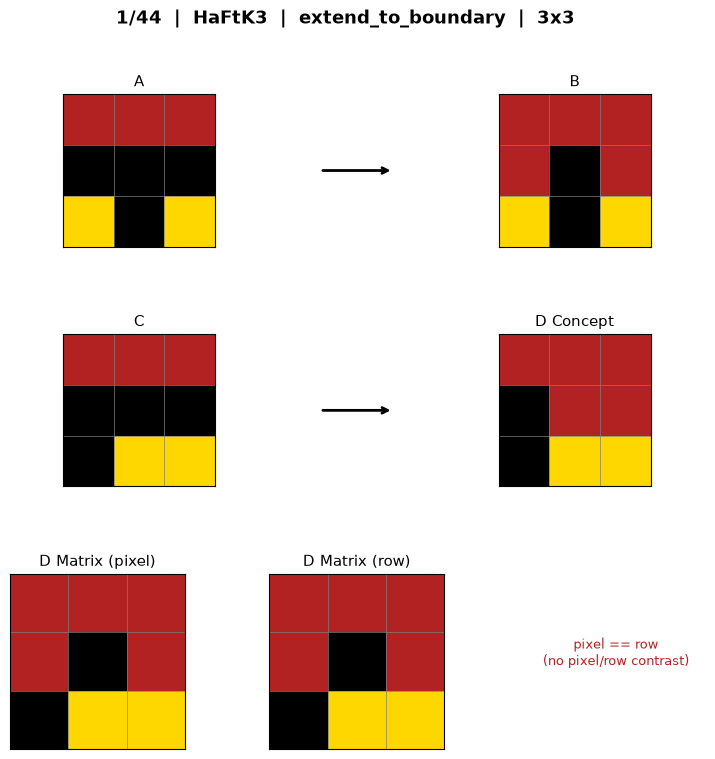

In [39]:
reviewer.reject()                      # drop


In [131]:
reviewer.summary()     # concept x size table
reviewer.items         # updated list (deep copy — items_data untouched)
reviewer.save('data/new_items/items_updated.json')

Wrote 308 items to data/new_items/items_updated.json (4 newly accepted)


# Process data exploration

In [36]:
process_df = pd.read_csv(
    "data/human_data_collection/process_demo.csv",
    dtype={"state": "string"},
)

process_df

,process_id,participant_fk,itemid,task,page_id,event_idx,action,cell,color,state,t_ms,saved_at
0,1,1404,Fnkg2A_1,generation,38b070ff7c3014bd,0,select,NaN,3.0,000000000,5366,2026-09-29 16:13:28
1,2,1404,Fnkg2A_1,generation,38b070ff7c3014bd,1,draw,4.0,3.0,000300000,6033,2026-09-29 16:13:28
2,3,1404,Fnkg2A_1,generation,38b070ff7c3014bd,2,draw,5.0,3.0,000330000,6451,2026-09-29 16:13:28
3,4,1404,Fnkg2A_1,generation,38b070ff7c3014bd,3,draw,8.0,3.0,000330030,6808,2026-09-29 16:13:28
4,5,1404,Fnkg2A_1,generation,38b070ff7c3014bd,4,select,NaN,4.0,000330030,7607,2026-09-29 16:13:28
...,...,...,...,...,...,...,...,...,...,...,...,...
61,62,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,7,draw,19.0,3.0,0000000000555550003000000,6457,2026-09-29 16:14:27
62,63,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,8,draw,20.0,3.0,0000000000555550003300000,6793,2026-09-29 16:14:27
63,64,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,9,draw,24.0,3.0,0000000000555550003300030,7179,2026-09-29 16:14:27
64,65,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,10,draw,25.0,3.0,0000000000555550003300033,7455,2026-09-29 16:14:27


In [37]:
process_df

,process_id,participant_fk,itemid,task,page_id,event_idx,action,cell,color,state,t_ms,saved_at
0,1,1404,Fnkg2A_1,generation,38b070ff7c3014bd,0,select,NaN,3.0,000000000,5366,2026-09-29 16:13:28
1,2,1404,Fnkg2A_1,generation,38b070ff7c3014bd,1,draw,4.0,3.0,000300000,6033,2026-09-29 16:13:28
2,3,1404,Fnkg2A_1,generation,38b070ff7c3014bd,2,draw,5.0,3.0,000330000,6451,2026-09-29 16:13:28
3,4,1404,Fnkg2A_1,generation,38b070ff7c3014bd,3,draw,8.0,3.0,000330030,6808,2026-09-29 16:13:28
4,5,1404,Fnkg2A_1,generation,38b070ff7c3014bd,4,select,NaN,4.0,000330030,7607,2026-09-29 16:13:28
...,...,...,...,...,...,...,...,...,...,...,...,...
61,62,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,7,draw,19.0,3.0,0000000000555550003000000,6457,2026-09-29 16:14:27
62,63,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,8,draw,20.0,3.0,0000000000555550003300000,6793,2026-09-29 16:14:27
63,64,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,9,draw,24.0,3.0,0000000000555550003300030,7179,2026-09-29 16:14:27
64,65,1404,6t9NbZ_1,generation,7bb17a7e29373c7a,10,draw,25.0,3.0,0000000000555550003300033,7455,2026-09-29 16:14:27
